https://astroautomata.com/blog/simulation-based-inference/

In [62]:
import torch
from sbi.inference import NPE
from sbi import utils
from sbi.inference import simulate_for_sbi

prior = utils.BoxUniform(
    low=torch.tensor([-5., -5.]),
    high=torch.tensor([5., 5.])
)

def simulator(theta):
    return theta + 0.5 * torch.randn_like(theta)

# Generate simulations
inference = NPE(prior=prior)

theta, x = simulate_for_sbi(
    simulator=simulator,
    proposal=prior,
    num_simulations=200,
)

# Train neural density estimator
density_estimator = (
    inference
    .append_simulations(theta, x)
    .train()
)

# Build posterior
posterior = inference.build_posterior(density_estimator)

100%|██████████| 200/200 [00:00<00:00, 82144.61it/s]


 Neural network successfully converged after 137 epochs.

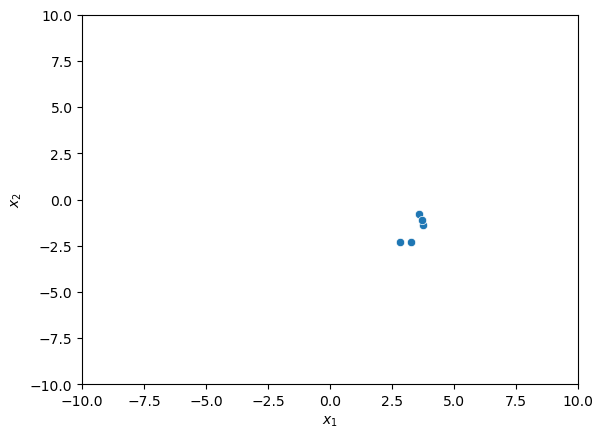

In [63]:
import seaborn as sns
from matplotlib import pyplot as plt

# record 5 observations
n_observations = 5
observation = (
    torch.tensor([3., -1.5])[None]
    + 0.5 * torch.randn(n_observations, 2)
)

sns.scatterplot(
    x=observation[:, 0].numpy(),
    y=observation[:, 1].numpy()
)

plt.xlabel(r'$x_1$')
plt.ylabel(r'$x_2$')
plt.xlim(-10, 10)
plt.ylim(-10, 10)
plt.show()

299it [00:00, 30743.70it/s]            


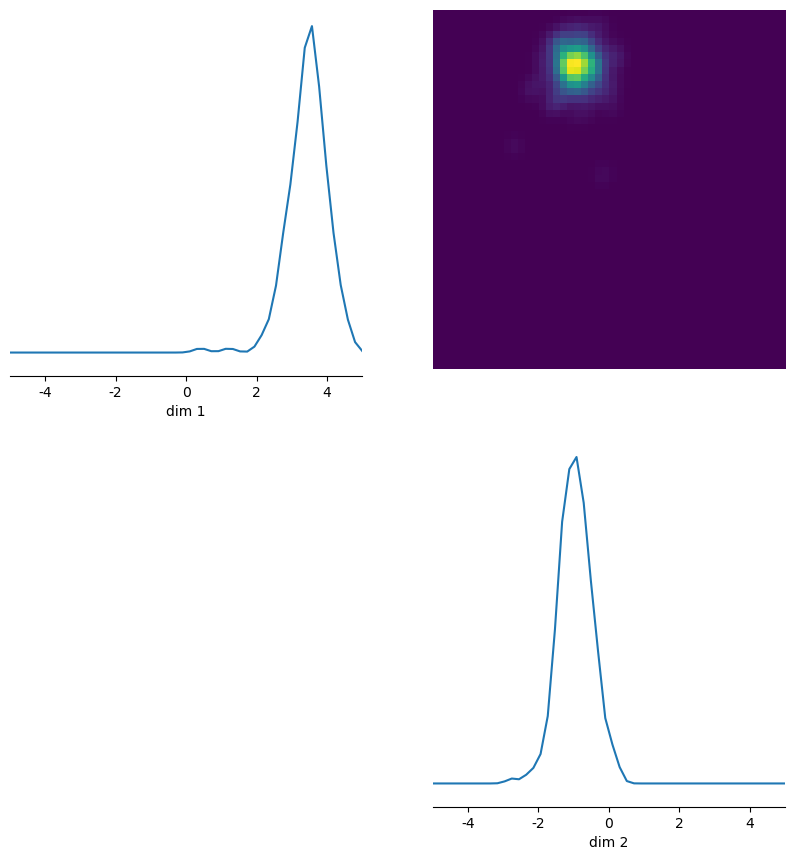

In [64]:
from sbi.analysis import pairplot

samples = posterior.sample((200,), x=observation[0])

log_probability = posterior.log_prob(samples, x=observation[0])

out = pairplot(
    samples,
    limits=[[-5,5],[-5,5]],
    fig_size=(1,1),
    upper='kde',
    diag='kde'
)

Text(0, 0.5, '$\\mu_2$')

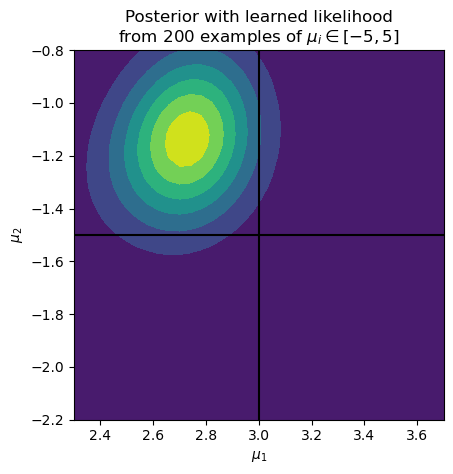

In [65]:
# calc log likelihood
import numpy as np

# define grid
bounds = [3-1, 3+1, -1.5-1, -1.5+1]

mu_1, mu_2 = torch.tensor(np.mgrid[bounds[0]:bounds[1]:2/50., bounds[2]:bounds[3]:2/50.]).float()

grids = torch.cat(
    (mu_1.reshape(-1, 1), mu_2.reshape(-1, 1)),
    dim=1
)

# calc
log_prob = sum(
    posterior.log_prob(grids, x=observation[i])
    for i in range(len(observation))
)

prob = torch.exp(log_prob - log_prob.max())
plt.figure()
plt.plot([2, 4], [-1.5, -1.5], color='k')
plt.plot([3, 3], [-0.5, -2.5], color='k')
plt.contourf(prob.reshape(*mu_1.shape), extent=bounds, origin='lower')
plt.axis('scaled')
plt.xlim(2+0.3, 4-0.3)
plt.ylim(-2.5+0.3, -0.5-0.3)
plt.title('Posterior with learned likelihood\nfrom %d examples of'%(num_sim)+r' $\mu_i\in[-5, 5]$')
plt.xlabel(r'$\mu_1$')
plt.ylabel(r'$\mu_2$')

Text(0, 0.5, '$\\mu_2$')

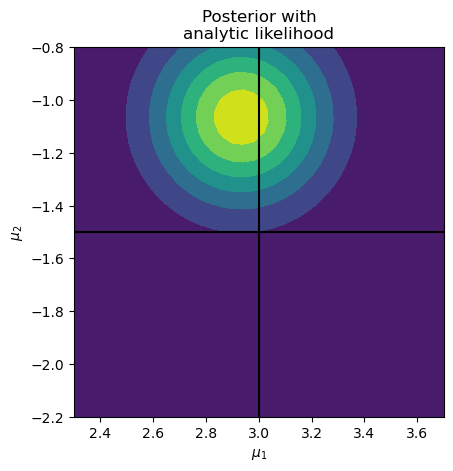

In [66]:
# true log likelihood
true_like = lambda x: -((x[0] - mu_1)**2 + (x[1] - mu_2)**2)/(2*0.5**2)
log_prob = sum([true_like(observation[i]) for i in range(len(observation))])

plt.figure()
prob = torch.exp(log_prob - log_prob.max())
plt.plot([2, 4], [-1.5, -1.5], color='k')
plt.plot([3, 3], [-0.5, -2.5], color='k')
plt.contourf(prob.reshape(*mu_1.shape), extent=bounds, origin='lower')
plt.axis('scaled')
plt.xlim(2+0.3, 4-0.3)
plt.ylim(-2.5+0.3, -0.5-0.3)
plt.title('Posterior with\nanalytic likelihood')
plt.xlabel(r'$\mu_1$')
plt.ylabel(r'$\mu_2$')